
# Сравнение Uplift ML и DL моделей на датасете X5

В ноутбуке строится единый пайплайн для:
- `T-Learner (LogReg)`
- `X-Learner (CatBoost)`
- `T-Learner NN`
- `S-Learner NN`
- `TARNet (Classic MLP)`
- `TARNet (Attention)`

Логика сравнения:
1. Стоятся `expanded` признаки через `UpliftFeatureExtractorExpanded`;
2. Для ML-моделей и TARNet-моделей используются `UMAP + KMeans` кластерные признаки;
3. Производится расчет метрик по `train_oof` через CV на `train_full`;
4. Производится расчет метрик по `test_holdout`.

На предыдущем проектном этапе (Classic-ml-models\jupyter_results_comparison\All_models-new_feats_analysis.ipynb) мы провели сравнительный анализ используемых Classic ML моделей в построении uplift-моделирования с учетом кластерных признаков и калибровки. Ранее, в рамках EDA-анализа (Feature-engineering\Exploratory_analysis.ipynb) мы оценили сбалансированность выборки данных и позже провели сравнение построенных моделей с бейзлайном (Classic-ml-models\jupyter_results_comparison\Models-vs-baseline_analysis.ipynb). В рамках сопоставления лучших ML-подходов с DL-моделями в качестве архитектур со стороны ML были выбраны X-learner с использованием CatBoost и T-learner на основе логарифмической регрессии исходя из аргументации, предложенной на предыдущем этапе.

Для DL-подходов мы сознательно сохранили вход в виде агрегированных признаков, построенных на этапе EDA, а не перешли к сырым транзакционным данным. Это связано с тем, что в данной задаче X5 имеет табличную природу, и именно агрегаты покупательской истории клиента выступают наиболее естественным и устойчивым представлением его поведения. Кроме того, сам датасет не задает явной последовательностной структуры для таргета: таргет не привязан к конкретной покупке во времени, а также отсутствует информация о механике формирования treatment/control групп и о точном моменте появления целевого события относительно транзакций (точнее, упоминается, что транзакции были произведены prior to communication, т.е. являются историческими данными клиента). Поэтому временные подходы, включая ранее предложенные рекуррентные архитектуры, либо потребовали бы слишком сильной искусственной абстракции над исходными данными, либо не давали бы содержательно обоснованного преимущества. В этой постановке более корректно и методологически оправданно использовать именно агрегированные клиентские признаки как вход для DL-моделей, которые в том числе показали свою эффективность в uplift-прогнозировании в Classic ML реализациях.

В данном ноутбуке обучение DL-моделей производилось на T4 (Colab-версия). В связи с этим в импорты пайплайн обучения и валидации добавлено флагирование на случай использования Google Colab, чтобы произведенный пайплайн мог быть повторен в исходной конфигурации.


## Подготовка к валидации

Основные и вспомогательные функции представлены в следующих модулях:
- В DL-ml-models\helpers\models_specs_and_vizuals.py представлен пайплайн обучения и валидации моделей;
- В DL-ml-models\helpers\uplift_dl_models.py представлены рализации DL-подходов (с некоторыми изменениями относительно частных реализаций), тюнинг которых был произведен в отдельных ноутбуках в DL-ml-models\jupyter_models_analysis;
- В DL-ml-models\helpers\classic_ml_models.py представлены реализации Classic ML-подходов;
- В DL-ml-models\helpers\feature_extraction_expanded.py и DL-ml-models\helpers\clusterization_features_extraction.py представлены экстракторы исходных признаков;
- В DL-ml-models\helpers\metrics.py представлены как uplift, так и бизнес-метрики;
- В DL-ml-models\helpers\dl_model_activations.py представлена реализация оценки значимости признаков исходя из активаций в DL-подходе (для каждой модели своя реализация).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import gc
import random
import importlib
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold

import sklearn.utils

if not hasattr(sklearn.utils, 'check_matplotlib_support'):
    sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

import sklift.viz.base as sklift_viz
from sklift.datasets import fetch_x5

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    parent_dir = Path('/content')
else:
    parent_dir = Path.cwd().resolve()

    if not (parent_dir / 'helpers').exists() and (parent_dir.parent / 'helpers').exists():
        parent_dir = parent_dir.parent

helpers_dir = parent_dir / 'helpers'

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

if str(helpers_dir) not in sys.path:
    sys.path.insert(0, str(helpers_dir))

(helpers_dir / '__init__.py').touch(exist_ok=True)

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

importlib.invalidate_caches()

from helpers.feature_extraction_expanded import UpliftFeatureExtractorExpanded
from helpers.models_specs_and_vizuals import *
from helpers.dl_model_activations import *
from helpers.uplift_dl_models import (
    set_global_seed,
    get_default_dl_model_configs,
)

In [9]:
# Фикс визуализации sklift-кривых
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}

    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and 'Random' not in labels:
        ax.plot(x_base, y_base, label='Random', color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel('Percent of population targeted')
        ax.set_ylabel('Incremental Outcome (Qini)')
    else:
        ax.set_xlabel('Number targeted')
        ax.set_ylabel('Cumulative Uplift')

    return self

sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [10]:
TARGET_COL = 'target'
TREATMENT_COL = 'treatment_flg'

HOLDOUT_SIZE = 0.2
N_SPLITS = 5
TOP_K_PERCENT = 0.30
N_CLUSTERS = 5

MODEL_ORDER = [
    'T-Learner (LogReg)',
    'X-Learner (CatBoost)',
    'T-Learner NN',
    'S-Learner NN',
    'TARNet (Classic MLP)',
    'TARNet (Attention)',
]

MODEL_COLORS = {
    'T-Learner (LogReg)': '#1f77b4',
    'X-Learner (CatBoost)': '#ff7f0e',
    'T-Learner NN': '#2ca02c',
    'S-Learner NN': '#d62728',
    'TARNet (Classic MLP)': '#9467bd',
    'TARNet (Attention)': '#8c564b',
}

MODEL_STYLES = {
    'T-Learner (LogReg)': {'ls': '-', 'alpha': 0.90},
    'X-Learner (CatBoost)': {'ls': '-', 'alpha': 1.00},
    'T-Learner NN': {'ls': '--', 'alpha': 0.95},
    'S-Learner NN': {'ls': ':', 'alpha': 0.95},
    'TARNet (Classic MLP)': {'ls': '-.', 'alpha': 0.95},
    'TARNet (Attention)': {'ls': '-', 'alpha': 0.95},
}

DL_CONFIGS = get_default_dl_model_configs()
DL_CONFIGS

{'t_learner_nn': {'hidden_dims': [64, 32],
  'dropout': 0.22338843352395796,
  'lr': 0.00032488253588586755,
  'batch_size': 512,
  'epochs': 60},
 's_learner_nn': {'cat_embed_dim': 8,
  'hidden_dims': [64, 32],
  'dropout': 0.20295116715006706,
  'lr': 0.0009865977951798554,
  'batch_size': 512,
  'epochs': 30},
 'tarnet_classic': {'shared_hidden': [128, 64],
  'head_hidden': [32, 16],
  'cat_emb_dim': 8,
  'dropout': 0.2,
  'lr': 0.001,
  'n_epochs': 40,
  'batch_size': 512},
 'tarnet_attention': {'d_model': 32,
  'n_heads': 4,
  'n_layers': 2,
  'mlp_hidden': 64,
  'dropout': 0.2,
  'lr': 0.0005,
  'n_epochs': 50,
  'batch_size': 1024}}

In [ ]:
# Загрузка X5 и построение expanded features
set_global_seed(SEED)

dataset = fetch_x5()
data = dataset.data

extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases,
)

del data, dataset
gc.collect()

features = extractor.feature_names
x_all_raw = df[features].copy()
y_all = df[TARGET_COL].to_numpy()
t_all = df[TREATMENT_COL].to_numpy()

print('Full feature matrix:', x_all_raw.shape)
print('Positive rate:', y_all.mean().round(4))
print('Treatment rate:', t_all.mean().round(4))
print('n features:', len(features))

Full feature matrix: (200039, 45)
Positive rate: 0.6199
Treatment rate: 0.4998
n features: 45


In [12]:
# Holdout split
strata_all = make_strata(y_all, t_all)

x_train_full_raw, x_test_holdout_raw, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    x_all_raw,
    y_all,
    t_all,
    test_size=HOLDOUT_SIZE,
    random_state=SEED,
    stratify=strata_all,
)

print('x_train_full_raw:', x_train_full_raw.shape)
print('x_test_holdout_raw:', x_test_holdout_raw.shape)
print('train target mean:', round(y_train_full.mean(), 4), '| train treatment mean:', round(t_train_full.mean(), 4))
print('test target mean:', round(y_test_holdout.mean(), 4), '| test treatment mean:', round(t_test_holdout.mean(), 4))

x_train_full_raw: (160031, 45)
x_test_holdout_raw: (40008, 45)
train target mean: 0.6199 | train treatment mean: 0.4998
test target mean: 0.6199 | test treatment mean: 0.4998


## Обучение и валидация на OOF и holdout-метриках

В качестве нейросетевых uplift-моделей были выбраны два классических metalearner-подхода - `S-Learner` и `T-Learner`, а также две архитектуры семейства `TARNet`: обычная MLP-версия и версия с self-attention. Такой выбор покрывает два разных класса решений. `S-Learner NN` и `T-Learner NN` дают понятные и интерпретируемые нейросетевые аналоги стандартных uplift-подходов: в первом случае одна модель получает `treatment` как входной признак, во втором обучаются две независимые outcome-модели для treatment и control. `Classic TARNet` и `Attention TARNet` уже моделируют потенциальные исходы через общее скрытое представление клиента и две отдельные головы для treatment/control, то есть позволяют сети самой выучивать гетерогенность эффекта на более глубоком уровне. В итоговом модуле именно эти четыре архитектуры реализованы как основной DL-стек: `T-Learner NN` - через два отдельных MLP-классификатора, `S-Learner NN` - через mixed-input MLP с embeddings категориальных признаков и treatment-входом, `Classic TARNet` - через shared MLP representation и две outcome-head, а `Attention TARNet` - через токенизацию числовых и категориальных признаков, transformer encoder и две outcome-head.

От нейросетевого `X-Learner` мы отказались потому, что в данной постановке он получился бы слишком тяжёлым и нестабильным инженерно. Его нейросетевой аналог потребовал бы отдельного обучения outcome-моделей, propensity-модели и effect-моделей на псевдо-эффектах, то есть многостадийного пайплайна с дополнительным источником шума и ошибками переноса между стадиями. Для табличной задачи такого размера это означало бы более сложную и менее устойчивую схему обучения, чем у `S/T-Learner` и `TARNet`, которые моделируют uplift более напрямую. `DragonNet` мы также сознательно не включали: эта архитектура естественнее работает в постановке, где treatment-assignment и propensity имеют явный причинный смысл и где есть содержательная информация о механизме разделения на группы. В нашем датасете такой информации нет: treatment/control заданы как готовый факт, но не раскрыт механизм назначения воздействия, а таргет не привязан к чёткой временной точке назначения и не сопровождается богатой информацией о propensity. Поэтому использование `DragonNet` и его propensity-head в данной задаче было бы скорее формальным, чем содержательно оправданным.

Изначально модели были построены как самостоятельные экспериментальные прототипы: с разной логикой preprocessing, разным способом подачи признаков и без общей инфраструктуры обучения. В итоговом модуле эти реализации были **унифицированы**: архитектурная идея каждой модели сохранена, а изменения касались в основном приведения их к единому production-like интерфейсу `fit / predict / predict_components`, добавления общего `eval_set`, early stopping, фиксации random seed, согласованного device-handling и совместимого preprocessing. Отдельные версии решали задачу "проверить, работает ли идея", а модульная версия - задачу "встроить все модели в единый OOF/holdout пайплайн и сравнивать их на одинаковых условиях". При этом гиперпараметры в модуле явно зафиксированы как конфиги, перенесённые из ноутбуков с минимальной унификацией.

На этапе отдельных экспериментов `S-Learner NN` и `T-Learner NN` использовались как более простые baseline-сетки на обычных агрегатах: их задача была дать понятный нейросетевой аналог классических metalearners. Позже, при переносе в единый модуль, эти модели были переведены на `expanded`-пространство признаков, чтобы сравнение с другими DL и ML-подходами шло в общем признаковом пространстве. Но при этом для них **не добавлялись UMAP-cluster features**: у `T-Learner NN` и так есть достаточно жёсткая схема "два отдельных MLP после общего tabular preprocessing", а у `S-Learner NN` - одна mixed-input сеть с embeddings категорий и treatment-входом. Для таких моделей кластерные признаки могли бы давать скорее дополнительный шум и смешивать baseline-роль модели с тяжёлым feature-engineering. В отличие от них, `TARNet`-модели специально оставлены на `expanded + cluster features`, потому что их архитектура строит **общее латентное представление клиента**, и кластерные признаки естественно работают как дополнительное описание положения клиента в поведенческом пространстве. Для `Attention TARNet` это особенно эффективно, так как модель оперирует токенами признаков и учит их взаимодействия через self-attention; для `Classic TARNet` - потому что shared representation с двумя outcome-head хорошо процессирует более богатое смешанное пространство входов. Это же разделение зафиксировано и в model specs: `T/S-Learner NN` получают plain feature view, а обе `TARNet`-модели - cluster-enriched view.

Размеры батча подбирались как инженерный компромисс между устойчивостью и скоростью обучения на табличных данных. Для `T-Learner NN`, `S-Learner NN` и `Classic TARNet` выбран `batch_size = 512`. Для `Attention TARNet` батч увеличен до `1024`, поскольку attention-версия в финальном конфиге использовалась как более тяжёлая, но хорошо векторизуемая модель, и больший батч здесь помогает уменьшить число итераций на эпоху и ускорить обучение без изменения общей архитектурной логики.


In [ ]:
# OOF на train_full
set_global_seed(SEED)

results_list = []
oof_train_preds = {model_name: np.zeros(len(x_train_full_raw), dtype=float) for model_name in MODEL_ORDER}

skf_inner = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
strata_train = make_strata(y_train_full, t_train_full)

for fold, (train_idx, valid_idx) in enumerate(skf_inner.split(x_train_full_raw, strata_train), start=1):

    x_tr_plain = x_train_full_raw.iloc[train_idx].copy()
    x_val_plain = x_train_full_raw.iloc[valid_idx].copy()
    y_tr = y_train_full[train_idx]
    y_val = y_train_full[valid_idx]
    t_tr = t_train_full[train_idx]
    t_val = t_train_full[valid_idx]

    clusterizer_fold, transformed = fit_cluster_views(x_tr_plain, x_val_plain, n_clusters=N_CLUSTERS, random_state=SEED)
    x_tr_cl, x_val_cl = transformed

    fold_specs = build_fold_model_specs(
        x_tr_plain=x_tr_plain,
        x_val_plain=x_val_plain,
        x_tr_cl=x_tr_cl,
        x_val_cl=x_val_cl,
        device=DEVICE,
    )

    for model_name in MODEL_ORDER:
        spec = fold_specs[model_name]
        fitted_model, preds_val = fit_model_and_predict(
            spec=spec,
            y_train=y_tr,
            t_train=t_tr,
            y_eval=y_val,
            t_eval=t_val,
        )

        oof_train_preds[model_name][valid_idx] = preds_val
        results_list.append({
            'Model': model_name,
            'Fold': fold,
            'Split': 'train_oof',
            **calculate_metrics(y_val, preds_val, t_val),
        })

        del fitted_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [ ]:
# Холдаут
set_global_seed(SEED)
RUN_ENV = 'colab' if IN_COLAB else 'local'

if IN_COLAB:
    MODEL_REPO_ROOT = Path('/content/models_saved')
else:
    MODEL_REPO_ROOT = Path(parent_dir) / 'models_saved'

ML_MODEL_REPO = MODEL_REPO_ROOT / 'ml'
DL_MODEL_REPO = MODEL_REPO_ROOT / 'dl'

ML_MODEL_REPO.mkdir(parents=True, exist_ok=True)
DL_MODEL_REPO.mkdir(parents=True, exist_ok=True)

USE_SAVED_ML_MODELS = False
SAVE_FITTED_ML_MODELS = True

USE_SAVED_DL_MODELS = False
SAVE_FITTED_DL_MODELS = True

# Кластерные фичи для всего трейна
clusterizer_full, transformed_full = fit_cluster_views(
    x_train_full_raw,
    x_test_holdout_raw,
    n_clusters=N_CLUSTERS,
    random_state=SEED,
)
x_train_full_clust, x_test_holdout_clust = transformed_full

# Спеки для холдаута
holdout_specs = build_holdout_model_specs(
    x_train_plain=x_train_full_raw,
    x_test_plain=x_test_holdout_raw,
    x_train_cl=x_train_full_clust,
    x_test_cl=x_test_holdout_clust,
    device=DEVICE,
)

test_holdout_preds = OrderedDict()
test_results_list = []

for model_name in MODEL_ORDER:
    spec = holdout_specs[model_name]
    model = spec['model']
    x_train = spec['x_train']
    x_test = spec['x_test']
    is_dl = spec['is_dl']

    model_key = make_model_key(model_name)

    if is_dl:
        model_path = DL_MODEL_REPO / f'{model_key}.pt'
    else:
        model_path = ML_MODEL_REPO / f'{model_key}.joblib'

    if is_dl:
        if USE_SAVED_DL_MODELS and model_path.exists():
            model = torch.load(model_path, map_location=DEVICE, weights_only=False)
            model = move_loaded_dl_model_to_device(model, DEVICE)
        else:
            # На holdout НЕ юзаем сам test_holdout как eval_set
            # чтобы не было leakage
            model.fit(x_train, y_train_full, t_train_full)

            if SAVE_FITTED_DL_MODELS:
                torch.save(model, model_path)

    else:
        if USE_SAVED_ML_MODELS and model_path.exists():
            bundle = joblib.load(model_path)
            model = bundle['model']
        else:
            model.fit(x_train, y_train_full, t_train_full)

            if SAVE_FITTED_ML_MODELS:
                joblib.dump({'model': model}, model_path)

    preds_test = np.asarray(model.predict(x_test)).reshape(-1)
    test_holdout_preds[model_name] = preds_test

    test_results_list.append({
        'Model': model_name,
        'Split': 'test_holdout',
        **calculate_metrics(y_test_holdout, preds_test, t_test_holdout),
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Анализ полученных оценок метрик

На текущем этапе помимо технических uplift-метрик, были добавлены также и бизнесовые (с учетом information lack).

Они считаются на верхней части базы (top-k), отсортированной по предсказанному uplift, то есть именно на том сегменте клиентов, которых модель считает наиболее перспективными для коммуникации (ниже дан анализ первых 30%).
- absolute_uplift@k - это разница этих конверсий в процентных пунктах, то есть прямой инкрементальный эффект коммуникации;
- relative_lift@k показывает тот же эффект в относительном виде, как прирост относительно baseline control-группы.
- наиболее значимыми являются incremental_buyers@k и incremental_buyers_per_1000@k: первая метрика оценивает ожидаемое число дополнительных покупателей, которое даст таргетирование top-k сегмента, а вторая нормирует этот эффект на 1000 коммуникаций, что удобно для сравнения моделей и для практической оценки эффективности кампании.

Таким образом, если классические uplift-метрики отвечают на вопрос, насколько хорошо модель ранжирует клиентов по ожидаемому эффекту, то бизнес-метрики переводят это качество в язык кампании: сколько клиентов мы таргетируем, какой фактический прирост конверсии получаем и сколько дополнительных покупок это даёт.

In [16]:
# Итоговый summary
cv_results_df = pd.DataFrame(results_list)
summary_cols = ['AUUC', 'Qini', 'WAU', 'Uplift@10%', 'Uplift@20%', 'Uplift@30%', 'Uplift@50%']

test_results_df = pd.DataFrame(test_results_list).set_index('Model').loc[MODEL_ORDER].reset_index()

train_summary = cv_results_df.groupby('Model')[summary_cols].mean().loc[MODEL_ORDER]
train_summary.columns = [f'{c} | train_oof' for c in train_summary.columns]

test_summary = test_results_df.set_index('Model')[summary_cols].loc[MODEL_ORDER]
test_summary.columns = [f'{c} | test_holdout' for c in test_summary.columns]

full_summary = train_summary.join(test_summary)
display(full_summary)

,AUUC | train_oof,Qini | train_oof,WAU | train_oof,Uplift@10% | train_oof,Uplift@20% | train_oof,Uplift@30% | train_oof,Uplift@50% | train_oof,AUUC | test_holdout,Qini | test_holdout,WAU | test_holdout,Uplift@10% | test_holdout,Uplift@20% | test_holdout,Uplift@30% | test_holdout,Uplift@50% | test_holdout
Model,,,,,,,,,,,,,,
T-Learner (LogReg),0.021190,0.013711,0.033714,0.099050,0.075678,0.065566,0.048084,0.020176,0.013039,0.033082,0.097495,0.075093,0.062677,0.047678
X-Learner (CatBoost),0.023215,0.014920,0.032662,0.101410,0.075186,0.064450,0.051688,0.021170,0.013834,0.033805,0.115990,0.078177,0.060855,0.047957
T-Learner NN,0.019968,0.012866,0.032888,0.097765,0.071769,0.063349,0.047853,0.009254,0.005965,0.033707,0.103847,0.068288,0.056988,0.037723
S-Learner NN,0.016858,0.010834,0.032634,0.076638,0.060317,0.054157,0.048345,0.017223,0.011208,0.033589,0.080860,0.074833,0.066029,0.042603
TARNet (Classic MLP),0.021218,0.013665,0.032726,0.100245,0.078763,0.066452,0.049437,0.016298,0.010562,0.033121,0.109235,0.069935,0.059544,0.040143
TARNet (Attention),0.019504,0.012546,0.033095,0.093281,0.068192,0.057292,0.048212,0.016121,0.010578,0.033869,0.109977,0.068116,0.063986,0.042870


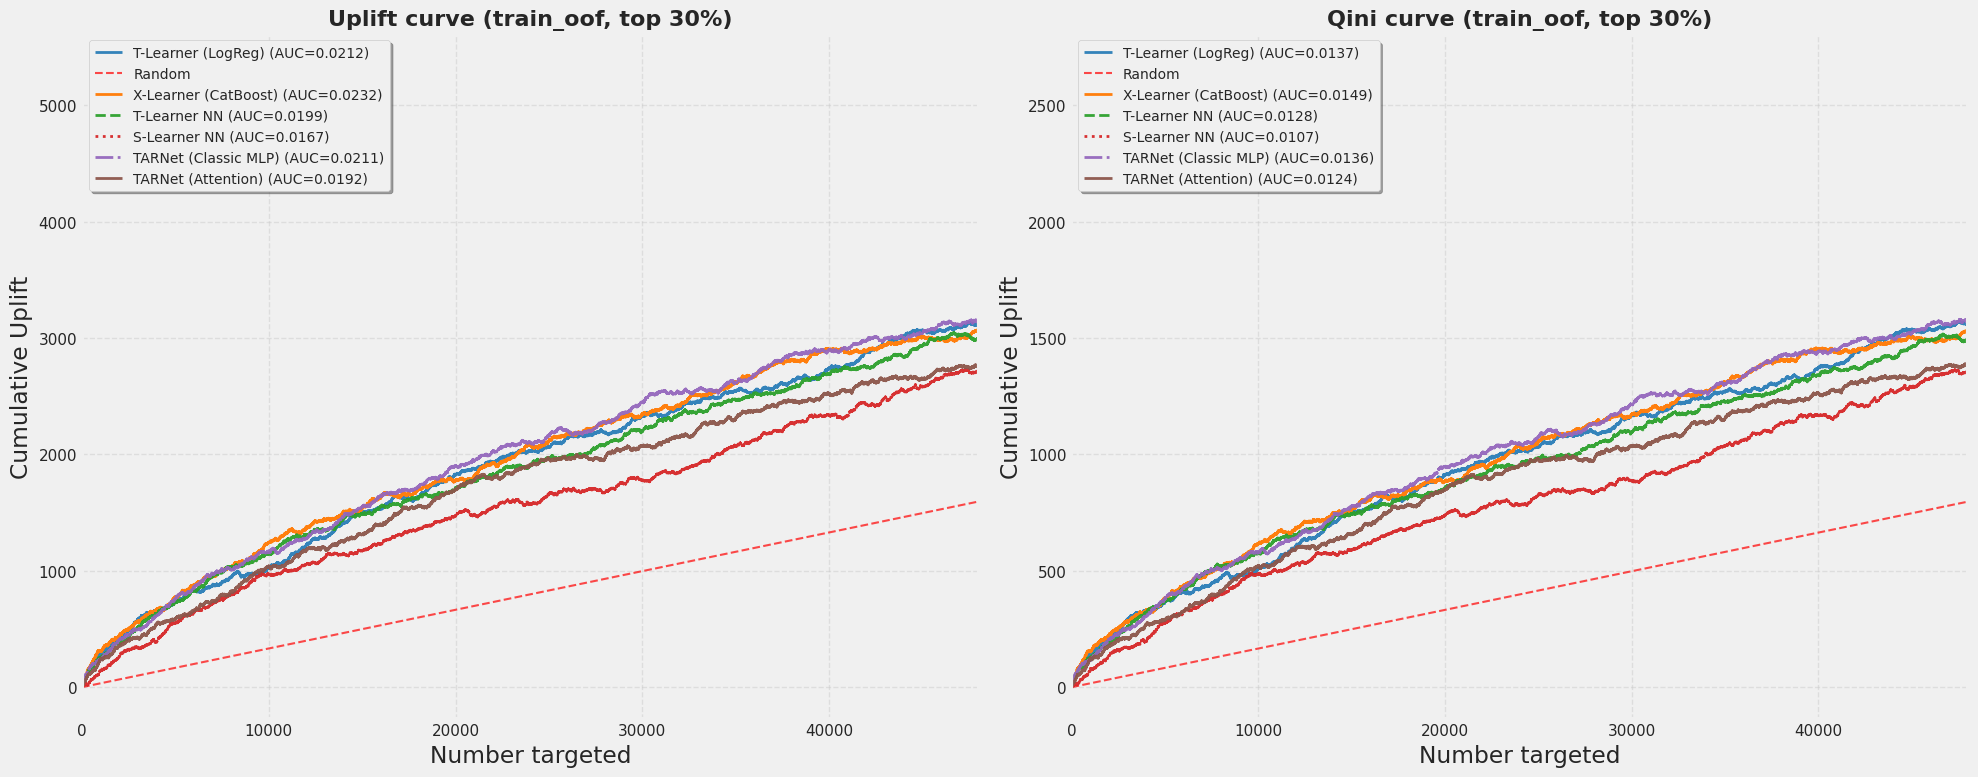

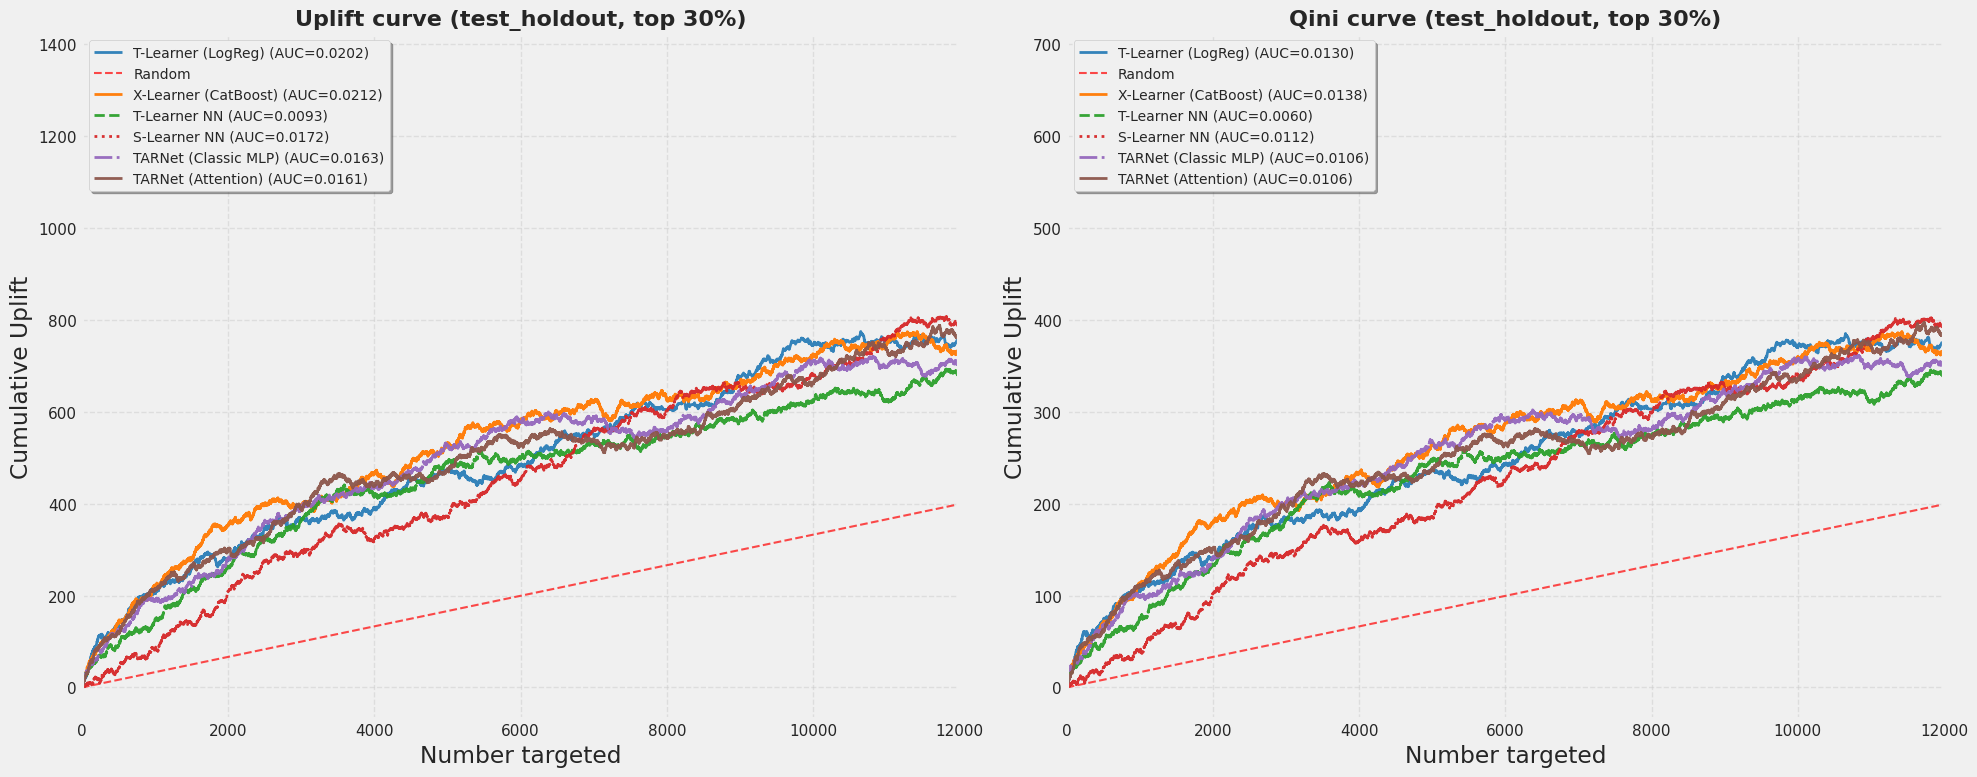

In [17]:
# Uplift/Qini curves
plot_curves_compare(
    preds_dict=oof_train_preds,
    y_true=y_train_full,
    treatment=t_train_full,
    split_name='train_oof',
    top_k_percent=TOP_K_PERCENT,
)

plot_curves_compare(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    top_k_percent=TOP_K_PERCENT,
)

**Анализ накопительных uplift-метрик на `train_oof` и `test_holdout`**

Если смотреть только на накопительные метрики качества ранжирования (`AUUC`, `Qini`, `WAU`, `Uplift@k`), то **оптимальной моделью на текущем этапе выглядит `X-Learner (CatBoost)`**. На `train_oof` он показывает лучшие значения `AUUC` и `Qini`, лучший `Uplift@10%`, а также высокий `Uplift@50%`, то есть хорошо поднимает вверх базы клиентов с максимальным ожидаемым эффектом и в целом качественно ранжирует объекты по uplift. На `test_holdout` он сохраняет лидерство по `AUUC`, `Qini`, `Uplift@10%` и `Uplift@20%`, а по `WAU` уступает совсем незначительно, что говорит о реальном переносе качества на отложенную выборку. Именно сочетание сильного `train_oof` и сохранения лидерства на holdout делает `X-Learner` наилучшим кандидатом по совокупности накопительных метрик.

**`T-Learner (LogReg)`** выглядит как наиболее сильная и стабильная альтернатива. Он немного уступает `X-Learner` по `AUUC/Qini`, но очень близок к нему на holdout и показывает лучший `WAU` на `train_oof`. Это означает, что модель хорошо обобщает и ранжирует клиентов достаточно ровно по всей верхней части базы..

Среди **DL-моделей** на `train_oof` лучшей из нейросетевых моделей выглядит **`TARNet (Classic MLP)`**: у него лучшие `AUUC` и `Qini` среди DL-подходов, а также сильные значения `Uplift@20%`, `Uplift@30%` и `Uplift@50%`. Однако на `test_holdout` этот результат не удерживается: метрики заметно снижаются, и преимущество над другими DL-моделями исчезает. **`Attention TARNet`** на обучающей части немного слабее классического TARNet, но на holdout ведёт себя сопоставимо и даже лучше по ряду top-k метрик, что можно интерпретировать как чуть более устойчивое поведение, хотя и без выхода на уровень лучших ML-моделей. **`S-Learner NN`** интересен тем, что на holdout он оказывается лучшим среди DL по `AUUC` и `Qini`, но проигрывает по `Uplift@10%`, то есть лучше выглядит как модель общего ранжирования, чем как модель агрессивного поиска самого ценного top-сегмента. **`T-Learner NN`** в текущем виде выглядит наименее удачным: на `train_oof` он ещё конкурентен, но на holdout качество резко проседает, особенно по `AUUC` и `Qini`, что похоже на слабое обобщение.

Графики uplift- и qini-кривых подтверждают тот же вывод. На `train_oof` верхнюю огибающую чаще формируют `X-Learner` и `Classic TARNet`, но на `test_holdout` уже именно **`X-Learner` и `T-Learner (LogReg)`** выглядят наиболее уверенно и стабильно, тогда как DL-кривые в среднем располагаются ниже и сильнее колеблются. Поэтому **по накопительным метрикам в качестве текущего лидера разумно выбрать `X-Learner (CatBoost)`**, а `T-Learner (LogReg)` оставить как сильную и более простую альтернативу.

При этом накопительные метрики полезны как первый фильтр, но они **не полностью отражают способность модели выделять именно sensitive-клиентов**, то есть тех, чьё решение реально меняется под воздействием коммуникации. Ниже мы отдельно посмотрим **бизнесовые метрики и non-cumulative uplift by percentile**, чтобы проверить, действительно ли лидер по `AUUC/Qini` лучше всего концентрирует инкрементальный эффект в верхних сегментах базы, а не просто хорошо накапливает uplift в среднем по выборке.


Ниже представлен анализ бизнес-метрик:

In [18]:
# Бизнесово-интерпретируемый subset метрик
business_cols = [
    'incremental_buyers@10%',
    'incremental_buyers_per_1000@10%',
    'relative_lift@10%',
    'incremental_buyers@20%',
    'incremental_buyers_per_1000@20%',
    'relative_lift@20%',
    'incremental_buyers@30%',
    'incremental_buyers_per_1000@30%',
    'relative_lift@30%',
]

print('CV mean business metrics')
display(cv_results_df.groupby('Model')[business_cols].mean().loc[MODEL_ORDER].sort_values('incremental_buyers@10%', ascending=False))

print('Holdout business metrics')
display(test_results_df.set_index('Model')[business_cols].loc[MODEL_ORDER].sort_values('incremental_buyers@10%', ascending=False))

CV mean business metrics


,incremental_buyers@10%,incremental_buyers_per_1000@10%,relative_lift@10%,incremental_buyers@20%,incremental_buyers_per_1000@20%,relative_lift@20%,incremental_buyers@30%,incremental_buyers_per_1000@30%,relative_lift@30%
Model,,,,,,,,,
X-Learner (CatBoost),323.919406,101.193192,0.219032,481.468096,75.205888,0.153549,617.818566,64.341509,0.128419
TARNet (Classic MLP),320.202825,100.032123,0.203941,503.900172,78.709805,0.157013,638.154652,66.459443,0.129201
T-Learner (LogReg),317.179615,99.087665,0.214630,484.241690,75.639127,0.155325,629.381948,65.545746,0.129772
T-Learner NN,313.170989,97.835360,0.192388,459.209336,71.729043,0.137381,608.857872,63.408158,0.119053
TARNet (Attention),299.113484,93.443763,0.195673,435.834323,68.077839,0.141623,550.666563,57.348075,0.117125
S-Learner NN,244.699950,76.444845,0.137879,385.919074,60.281018,0.109211,520.418666,54.197846,0.098358


Holdout business metrics


,incremental_buyers@10%,incremental_buyers_per_1000@10%,relative_lift@10%,incremental_buyers@20%,incremental_buyers_per_1000@20%,relative_lift@20%,incremental_buyers@30%,incremental_buyers_per_1000@30%,relative_lift@30%
Model,,,,,,,,,
X-Learner (CatBoost),464.968182,116.212992,0.261643,624.525030,78.046117,0.164114,729.430053,60.770645,0.123141
TARNet (Attention),440.918104,110.201976,0.245646,543.994545,67.982323,0.145775,768.935337,64.061929,0.133431
TARNet (Classic MLP),435.905700,108.949188,0.248197,558.529758,69.798770,0.152135,713.623989,59.453802,0.123932
T-Learner NN,416.501642,104.099386,0.207261,547.244533,68.388470,0.129431,685.104058,57.077735,0.105267
T-Learner (LogReg),390.985073,97.721838,0.216800,609.207304,76.131880,0.158625,753.193901,62.750471,0.126170
S-Learner NN,324.567826,81.121676,0.152819,599.621930,74.934008,0.143977,791.596673,65.949902,0.126079


Бизнес-метрики уточняют картину, полученную по накопительным uplift-метрикам, и показывают, сколько **дополнительных покупателей** модель реально способна принести в верхней части базы. На `train_oof` **`X-Learner (CatBoost)`** выглядит лучшим выбором для **узкой таргетированной кампании**: в top-10% он даёт максимальные `incremental_buyers@10% = 323.9`, лучший `incremental_buyers_per_1000@10% = 101.2` и наибольший `relative_lift@10% = 21.9%`, то есть именно в самом дорогом и ценном сегменте он лучше других концентрирует инкрементальный эффект. На `test_holdout` это преимущество становится ещё более выраженным: `X-Learner` сохраняет лидерство и в top-10% (`464.97` дополнительных покупателей, `116.21` на 1000 контактов, `relative_lift = 26.2%`), и в top-20% (`624.53` дополнительных покупателей), что подтверждает его практическую пригодность для сценария ограниченного маркетингового бюджета. При этом на более широком охвате, в top-30%, картина уже менее однозначна: на holdout лидером по абсолютному числу дополнительных покупателей становится **`S-Learner NN`** (`791.6`), очень близко идут **`TARNet (Attention)`** (`768.9`) и **`T-Learner (LogReg)`** (`753.2`), а максимальный относительный лифт в этом сегменте показывает `TARNet (Attention)` (`13.34%`). Это означает, что `X-Learner` оптимален именно как модель для **точечного отбора самого чувствительного топ-сегмента**, тогда как некоторые DL-подходы начинают выигрывать лишь при расширении кампании до более широкой доли базы. Следовательно, если бизнес-сценарий предполагает коммуникацию только с верхними 10–20% клиентов, то итоговый выбор в пользу **`X-Learner`** дополнительно подтверждается и бизнес-метриками; если же планируется широкий охват порядка 30% базы, то различия между моделями становятся менее тривиальными, и это нужно дополнительно проверить через non-cumulative uplift by percentile. В случае ритейл-логики из-за низкого в среднем прироста и cost-heavy массовой коммуникации именно вариант с таргетированием топ-сегмента является оптимальной стратегией.


Теперь посмотрим на перцентильный uplift:

In [19]:
# Percentile uplift tables
train_oof_percentiles_df = build_percentile_summary_table(
    preds_dict=oof_train_preds,
    y_true=y_train_full,
    treatment=t_train_full,
    split_name='train_oof',
    bins=10,
)

test_holdout_percentiles_df = build_percentile_summary_table(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    bins=10,
)

Percentile uplift table | train_oof


Перцентиль (бакет),S-Learner NN,T-Learner (LogReg),T-Learner NN,TARNet (Attention),TARNet (Classic MLP),X-Learner (CatBoost)
0-10,"+7.68% n=16004, t=8036, c=7968","+9.61% n=16004, t=8010, c=7994","+9.71% n=16004, t=8012, c=7992","+8.71% n=16004, t=8033, c=7971","+10.28% n=16004, t=7998, c=8006","+10.18% n=16004, t=7917, c=8087"
10-20,"+3.87% n=16003, t=7924, c=8079","+5.35% n=16003, t=7980, c=8023","+4.95% n=16003, t=7908, c=8095","+4.71% n=16003, t=7982, c=8021","+5.52% n=16003, t=7901, c=8102","+4.85% n=16003, t=8067, c=7936"
20-30,"+5.50% n=16003, t=8016, c=7987","+4.52% n=16003, t=8108, c=7895","+4.02% n=16003, t=7978, c=8025","+3.81% n=16003, t=8066, c=7937","+3.68% n=16003, t=8134, c=7869","+4.17% n=16003, t=7986, c=8017"
30-40,"+2.18% n=16003, t=7984, c=8019","+2.41% n=16003, t=7921, c=8082","+3.20% n=16003, t=8018, c=7985","+3.75% n=16003, t=7950, c=8053","+2.58% n=16003, t=7898, c=8105","+3.40% n=16003, t=7982, c=8021"
40-50,"+4.24% n=16003, t=7938, c=8065","+2.13% n=16003, t=8072, c=7931","+1.64% n=16003, t=8050, c=7953","+4.01% n=16003, t=7923, c=8080","+2.64% n=16003, t=8024, c=7979","+3.15% n=16003, t=7985, c=8018"
50-60,"+2.81% n=16003, t=7994, c=8009","+2.50% n=16003, t=7966, c=8037","+2.45% n=16003, t=7993, c=8010","+2.77% n=16003, t=7995, c=8008","+2.09% n=16003, t=8016, c=7987","+1.26% n=16003, t=8024, c=7979"
60-70,"+1.13% n=16003, t=7970, c=8033","+2.86% n=16003, t=7923, c=8080","+1.65% n=16003, t=7999, c=8004","+0.60% n=16003, t=7897, c=8106","+0.91% n=16003, t=8099, c=7904","+2.12% n=16003, t=7983, c=8020"
70-80,"+2.72% n=16003, t=8045, c=7958","+0.95% n=16003, t=7986, c=8017","+1.78% n=16003, t=8057, c=7946","+1.57% n=16003, t=8081, c=7922","+1.27% n=16003, t=7966, c=8037","+1.93% n=16003, t=7960, c=8043"
80-90,"+1.15% n=16003, t=8055, c=7948","+1.85% n=16003, t=8027, c=7976","+0.70% n=16003, t=7968, c=8035","+0.70% n=16003, t=7956, c=8047","+1.62% n=16003, t=8010, c=7993","+0.20% n=16003, t=8016, c=7987"
90-100,"+1.34% n=16003, t=8023, c=7980","+1.30% n=16003, t=7992, c=8011","+2.89% n=16003, t=8002, c=8001","+2.57% n=16003, t=8102, c=7901","+2.36% n=16003, t=7939, c=8064","+1.73% n=16003, t=8065, c=7938"


Percentile uplift table | test_holdout


Перцентиль (бакет),S-Learner NN,T-Learner (LogReg),T-Learner NN,TARNet (Attention),TARNet (Classic MLP),X-Learner (CatBoost)
0-10,"+8.11% n=4001, t=1974, c=2027","+9.77% n=4001, t=1991, c=2010","+10.41% n=4001, t=2012, c=1989","+11.02% n=4001, t=2006, c=1995","+10.89% n=4001, t=2035, c=1966","+11.62% n=4001, t=2004, c=1997"
10-20,"+6.94% n=4001, t=2020, c=1981","+5.23% n=4001, t=2013, c=1988","+3.27% n=4001, t=2008, c=1993","+2.57% n=4001, t=1999, c=2002","+3.07% n=4001, t=1987, c=2014","+4.01% n=4001, t=1988, c=2013"
20-30,"+4.79% n=4001, t=1987, c=2014","+3.82% n=4001, t=1960, c=2041","+3.52% n=4001, t=1967, c=2034","+5.54% n=4001, t=2039, c=1962","+4.03% n=4001, t=1963, c=2038","+2.61% n=4001, t=2005, c=1996"
30-40,"+1.66% n=4001, t=2055, c=1946","+3.10% n=4001, t=2013, c=1988","-0.08% n=4001, t=1970, c=2031","-0.96% n=4001, t=1946, c=2055","+1.27% n=4001, t=2017, c=1984","+3.37% n=4001, t=2028, c=1973"
40-50,"-0.11% n=4001, t=2036, c=1965","+1.65% n=4001, t=2018, c=1983","+1.48% n=4001, t=2060, c=1941","+3.38% n=4001, t=2004, c=1997","+1.12% n=4001, t=1966, c=2035","+2.08% n=4001, t=2047, c=1954"
50-60,"+1.25% n=4001, t=1966, c=2035","-0.02% n=4001, t=2000, c=2001","+1.10% n=4001, t=1955, c=2046","+1.88% n=4001, t=2053, c=1948","+4.40% n=4001, t=2002, c=1999","+1.90% n=4001, t=1991, c=2010"
60-70,"+2.96% n=4001, t=1964, c=2037","+2.14% n=4001, t=2030, c=1971","+3.23% n=4001, t=2026, c=1975","+2.14% n=4001, t=2023, c=1978","+0.55% n=4001, t=1992, c=2009","+2.61% n=4001, t=1961, c=2040"
70-80,"+4.97% n=4001, t=2033, c=1968","+2.76% n=4001, t=1980, c=2021","+2.09% n=4001, t=1948, c=2053","+2.49% n=4001, t=2006, c=1995","+3.23% n=4001, t=2049, c=1952","+2.45% n=4001, t=2027, c=1974"
80-90,"+0.86% n=4000, t=1998, c=2002","+2.69% n=4000, t=1976, c=2024","+4.11% n=4000, t=2015, c=1985","+2.24% n=4000, t=1947, c=2053","+0.44% n=4000, t=1985, c=2015","+1.88% n=4000, t=2026, c=1974"
90-100,"+2.21% n=4000, t=1963, c=2037","+2.00% n=4000, t=2015, c=1985","+4.43% n=4000, t=2035, c=1965","+3.41% n=4000, t=1973, c=2027","+3.95% n=4000, t=2000, c=2000","+1.22% n=4000, t=1919, c=2081"


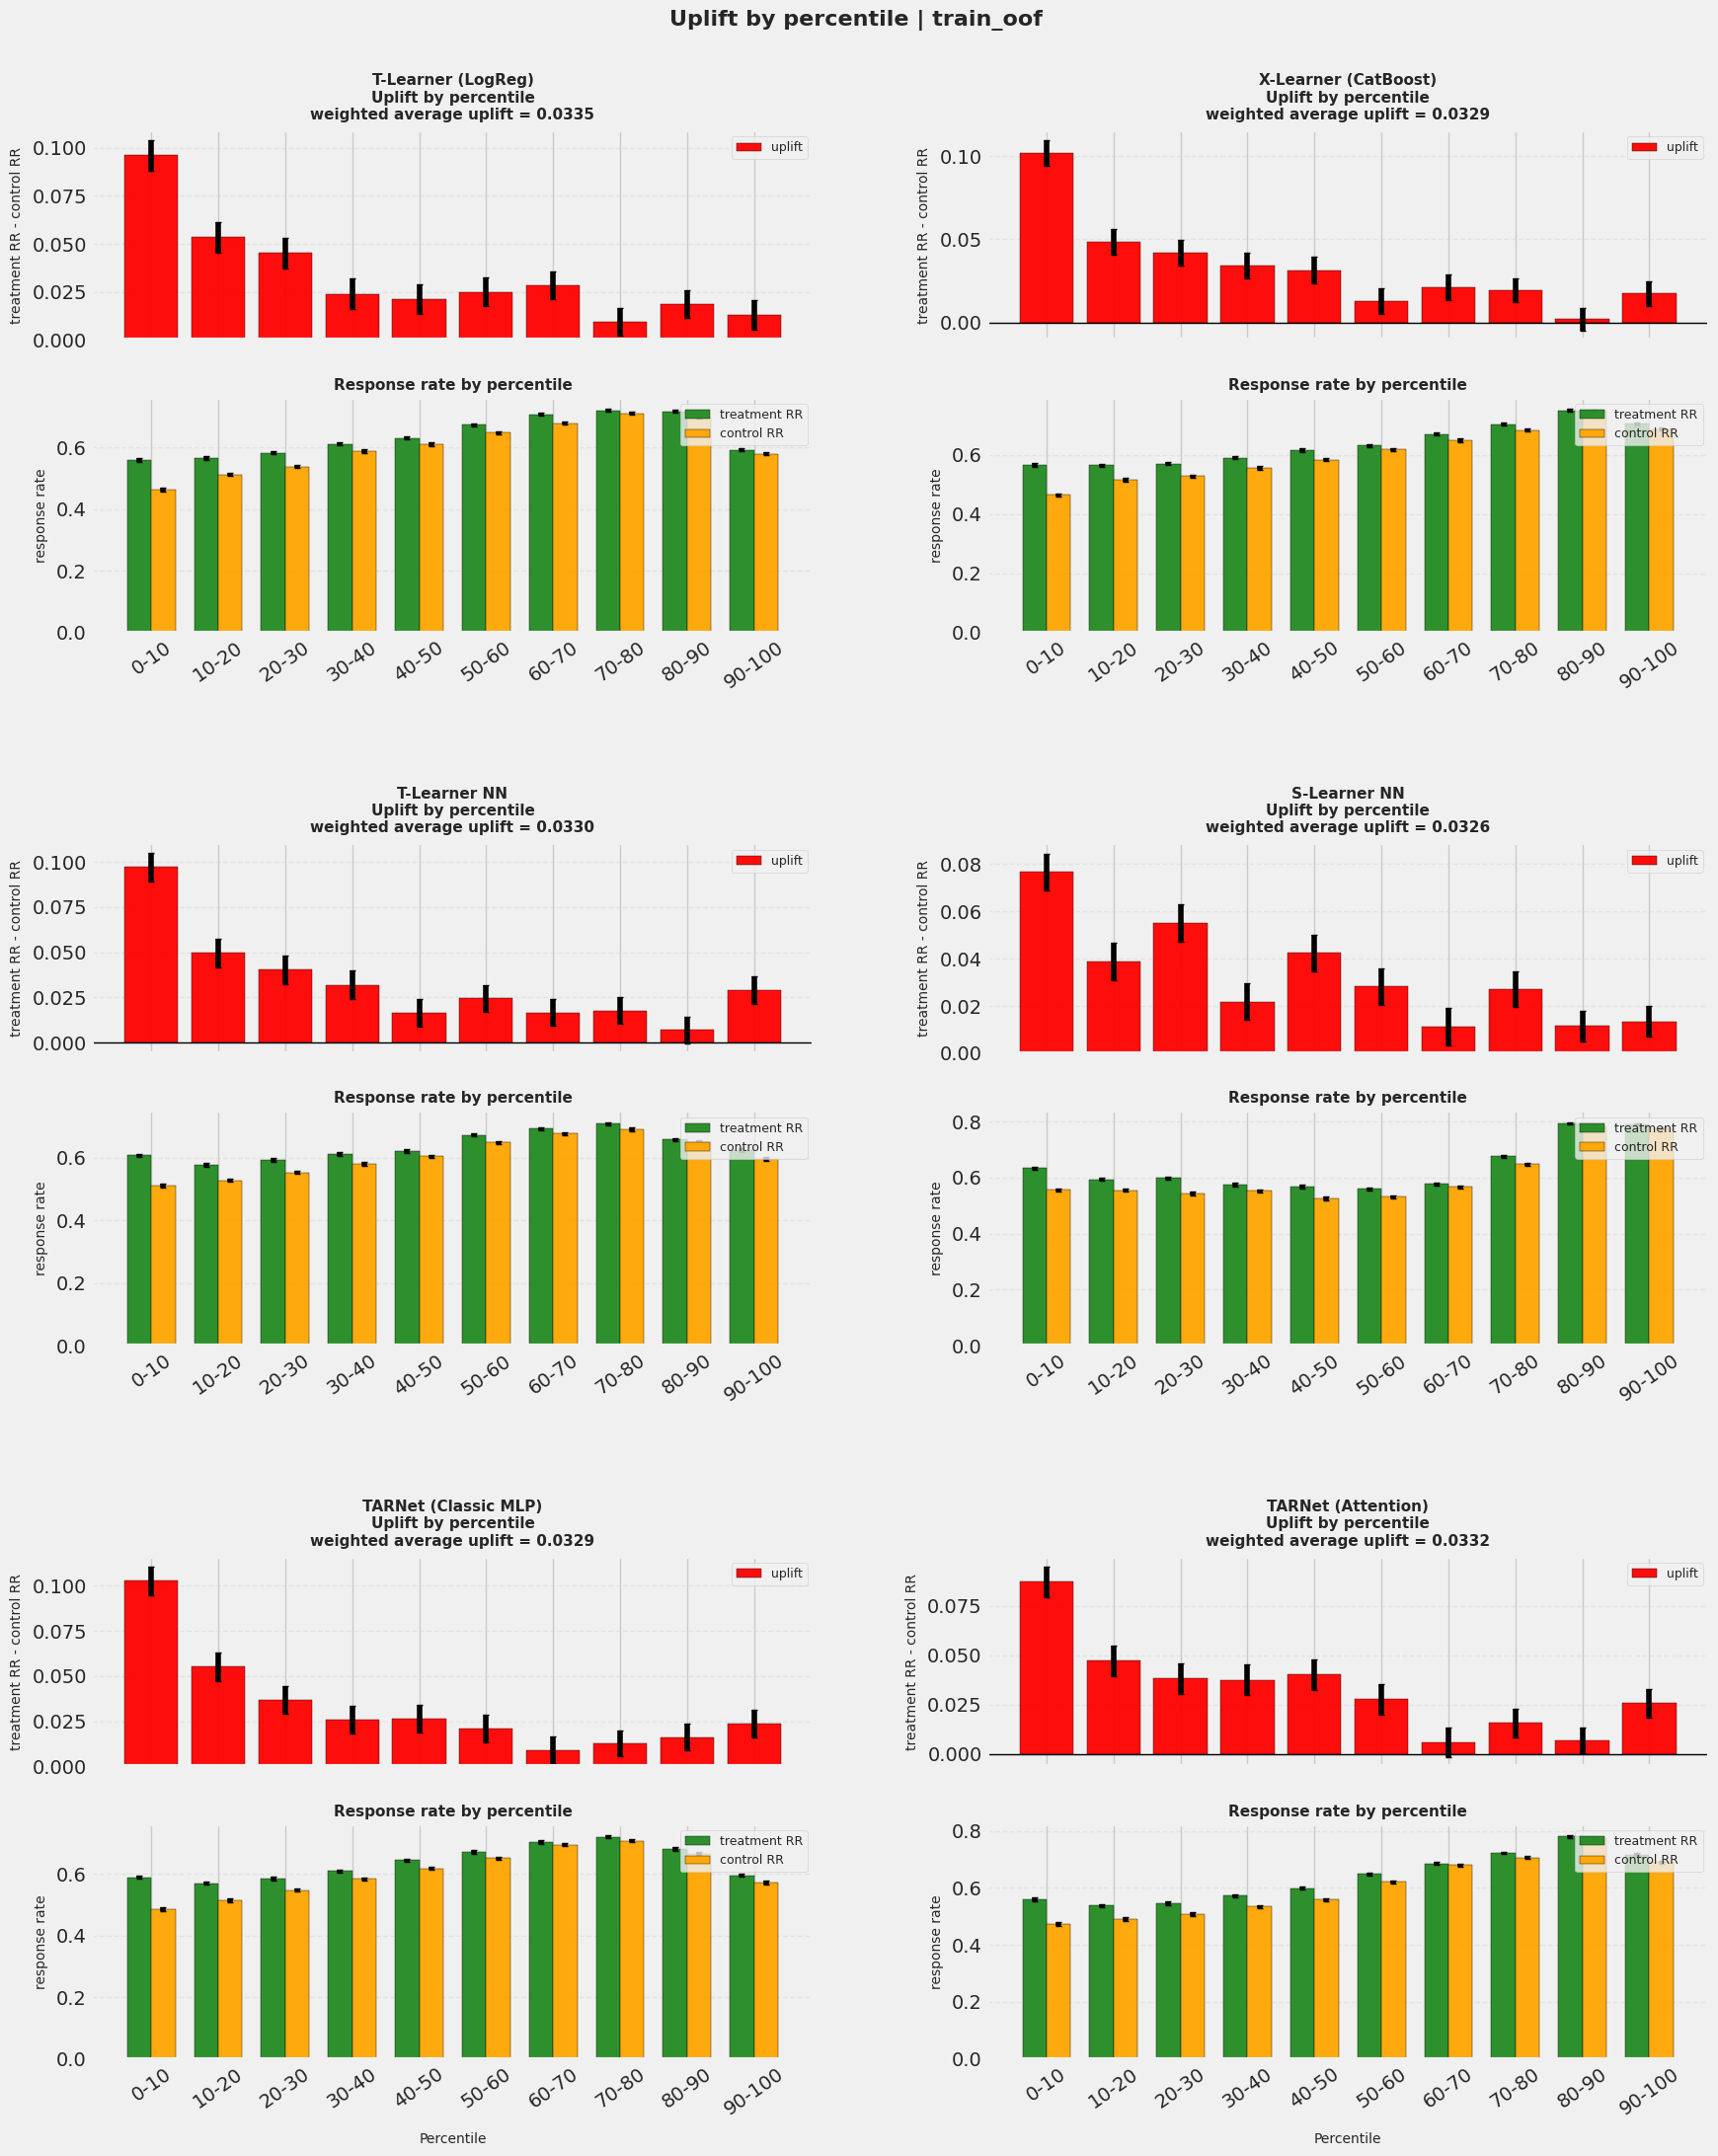

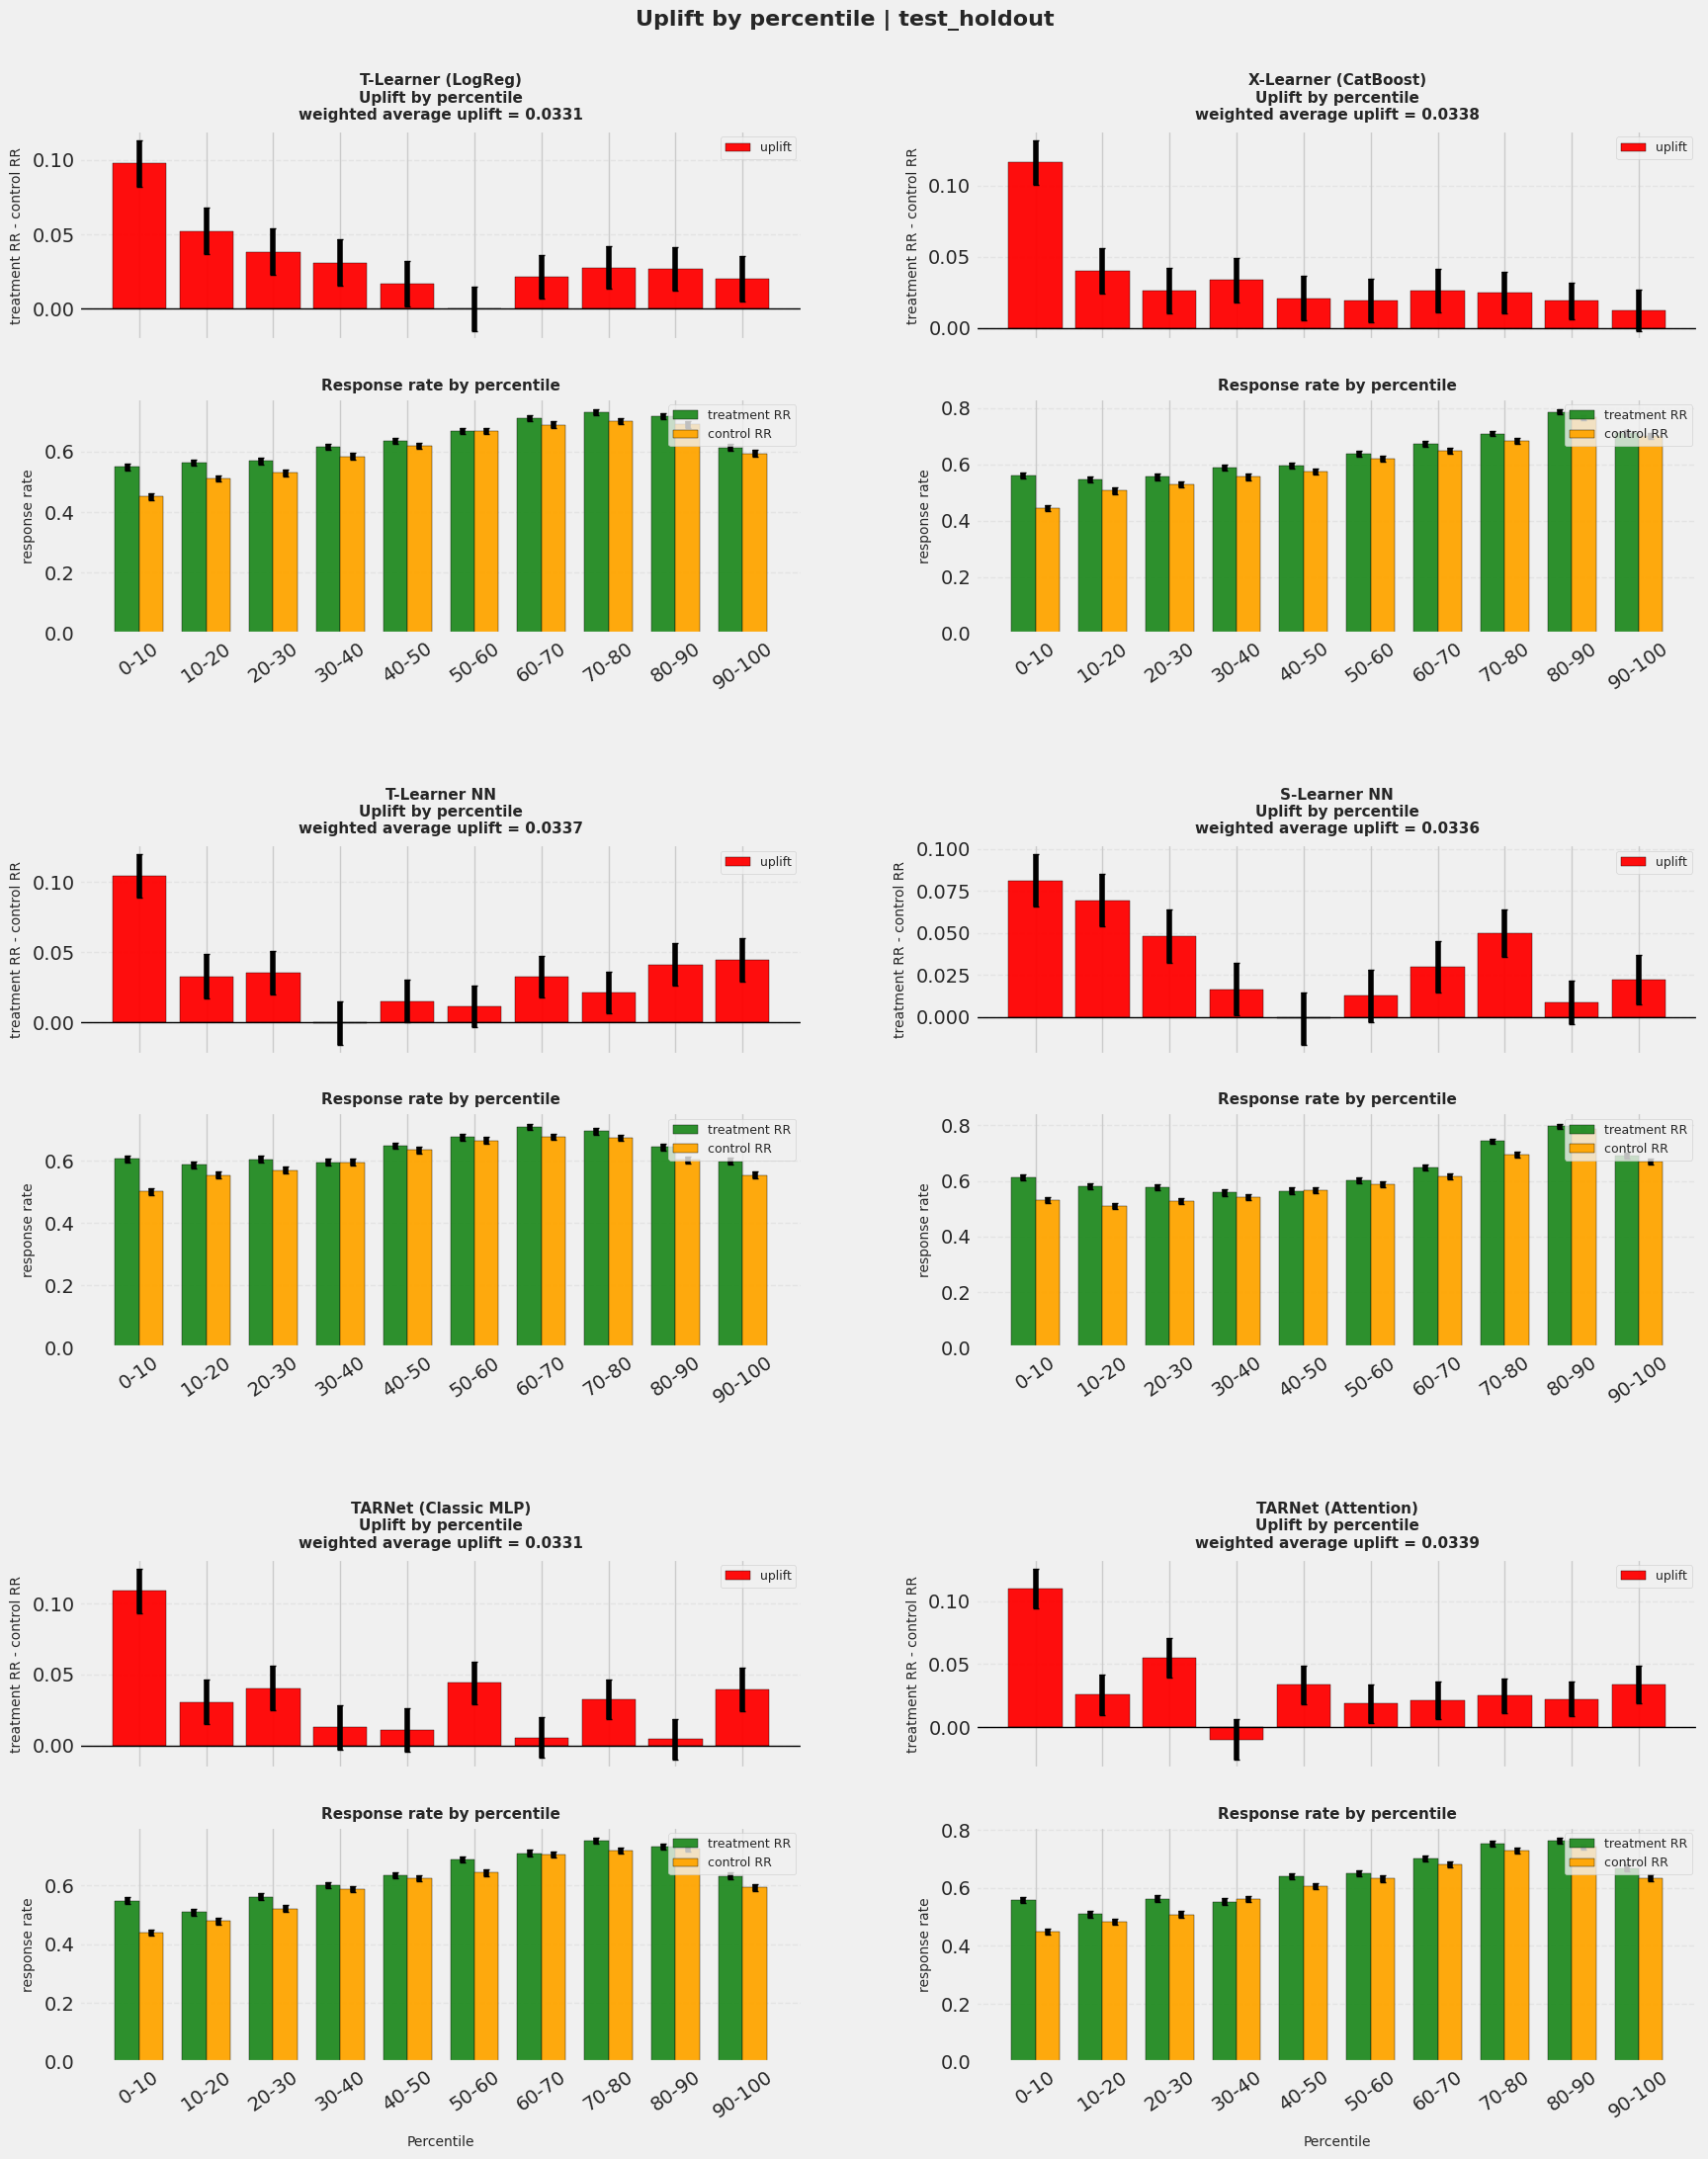

In [20]:
# Percentile uplift grids
plot_percentile_grid_any(
    preds_dict=oof_train_preds,
    y_true=y_train_full,
    treatment=t_train_full,
    split_name='train_oof',
    bins=10,
    ncols=2,
)

plot_percentile_grid_any(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    bins=10,
    ncols=2,
)

Именно **non-cumulative uplift by percentile** позволяет проверить, насколько модель действительно умеет поднимать наверх базы именно **sensitive / persuadable** клиентов, а не просто накапливает общий uplift за счёт широкой, но менее точной сортировки. На `train_oof` в первом дециле сильнее всего выступают `TARNet (Classic MLP)` и `X-Learner (CatBoost)`, а `T-Learner (LogReg)` показывает наиболее ровный профиль в первых 20–30% базы. Однако решающим является `test_holdout`. На holdout **лучший первый дециль** показывает именно **`X-Learner (CatBoost)`**: `+11.62%` в бакете `0–10%`, то есть он лучше остальных концентрирует максимальный инкрементальный эффект в самом ценном top-сегменте. В реальной компании верхние 10–20% базы обычно являются наиболее приоритетными. При этом `X-Learner` сохраняет **положительный uplift во всех бакетах**, без выраженных провалов в отрицательную зону. У `T-Learner (LogReg)` профиль также устойчивый: он немного слабее в первом бакете (`+9.77%`), но остаётся ровным и практически без деградации по всей шкале. DL-модели выглядят менее устойчиво: `TARNet (Attention)` и `Classic TARNet` способны давать очень сильные локальные бакеты, но у них появляются слабые или отрицательные сегменты в середине распределения; `S-Learner NN` неплох на `10–30%` и в отдельных дальних бакетах, но заметно проигрывает по top-10%; `T-Learner NN` даёт слишком высокий uplift в хвосте (`80–100%`), что скорее говорит не о силе модели, а о менее качественном ранжировании. Таким образом, по non-cumulative uplift видно, что **лучше всех верх базы ранжирует именно `X-Learner`**, а `T-Learner (LogReg)` остаётся наиболее стабильной альтернативой.


**Итоговый выбор лучшей модели**

Если собрать вместе **накопительные uplift-метрики**, **бизнес-метрики** и **non-cumulative uplift by percentile**, то итоговый выбор в пользу **`X-Learner (CatBoost)`** является наиболее обоснованным. Он лидирует по `AUUC` и `Qini`, показывает лучшие бизнес-результаты в top-10% и top-20% базы, а в percentile-анализе даёт максимальный uplift в первом дециле holdout - то есть лучше остальных находит именно тех клиентов, для которых коммуникация даёт наибольший инкрементальный эффект. `T-Learner (LogReg)` можно считать резервным вариантом: он чуть слабее по пиковому эффекту, но стабилен и хорошо обобщает. DL-модели в этой задаче оказались полезны скорее как исследовательский слой: они подтвердили наличие сложной гетерогенности эффекта, но в финальном сравнении либо уступили по топ-сегменту, либо показали менее устойчивое ранжирование на holdout. Поэтому **в качестве итоговой production-модели целесообразно выбрать `X-Learner (CatBoost)`**, а `T-Learner (LogReg)` сохранить как наиболее надёжный baseline.

Несмотря на то, что `TARNet` является специализированной uplift-архитектурой, в данной задаче он, как и остальные DL-модели, в итоге уступил лучшим ML-подходам. Основная причина в природе данных: мы работаем не с изображениями, текстом или длинными последовательностями, а с **табличными агрегированными признаками**, где деревья и бустинги традиционно чувствуют себя сильнее нейросетей. В таких данных сигнал задаётся комбинацией нелинейных, но относительно локальных правил по признакам, и `CatBoost`/логистические metalearner’ы умеют извлекать этот сигнал стабильнее и с меньшими требованиями к объёму данных и настройке обучения. Архитектура `TARNet` хорошо подходит для моделирования потенциальных исходов, но её преимущество раскрывается сильнее там, где есть либо более богатая структура входа, либо более выраженная сложная гетерогенность эффекта. В нашем случае вход уже сильно агрегирован, а значит часть информации о динамике поведения клиента заранее “сжата” на этапе feature engineering, и пространство для выигрыша глубокой сети уменьшается. Кроме того, DL-модели здесь в целом оказались более чувствительны к выбору batch size, регуляризации, глубины и representation space, из-за чего часть из них показывала неплохой `train_oof`, но менее устойчивое ранжирование на holdout.

Если развивать DL-направление, то следующий шаг - усилить **representation learning**. Один из возможных путей - добавить **VAE / denoising autoencoder** для предварительного обучения латентного представления клиента и уже на его основе учить uplift-head или TARNet-head; это могло бы помочь модели лучше структурировать табличное пространство и извлекать более устойчивые скрытые факторы поведения. Второй вариант - перейти к более GPU-heavy архитектурам для табличных данных: более глубоким residual MLP, FT-Transformer-подобным моделям, TabTransformer / SAINT-подобным схемам, либо к более мощной attention-модели с отдельным pretraining.


## Оценка значимости фичей через призму DL-модели

Хотя в продакшене в качестве основного решения у нас остаётся ML-подход, анализ важности признаков в DL-моделях всё равно полезен. Во-первых, это проверка **согласованности сигнала**: если и ML, и DL-модели выделяют похожие драйверы uplift, значит найденные закономерности не являются артефактом одной конкретной архитектуры. Во-вторых, DL-модели строят более сложные нелинейные представления клиента, поэтому такой анализ показывает не просто какие признаки важны сами по себе, а какие признаки начинают играть ключевую роль именно в более гибком representation learning. В коде важность считается не для propensity или обычной вероятности покупки, а именно для **uplift = p_treatment - p_control**, то есть интерпретируется вклад признаков в ожидаемый *инкрементальный эффект коммуникации*. Для `T-Learner NN` это делается через `|grad(uplift) * input|` на уже preprocessed-пространстве признаков с последующей агрегацией обратно к исходным raw features; такой подход оптимален, потому что модель состоит из двух отдельных outcome-сетей и работает после `ColumnTransformer` и one-hot представления. Для `S-Learner NN` сначала делаются два forward pass одной и той же сети - с `treatment=1` и `treatment=0`, после чего вклад числовых признаков и embedding-активаций категориальных признаков оценивается через разность градиентов между этими двумя режимами. Для `Classic TARNet` важность считается на общей скрытой репрезентации через `|grad * activation|` отдельно по числовым входам и embedding’ам категорий, что соответствует идее TARNet как модели с общим представлением клиента и двумя outcome-head. Для `Attention TARNet` логика та же, но attribution идёт не по исходным embedding’ам, а по **token-level активациям** после токенизации числовых и категориальных признаков, поэтому такая интерпретация отражает, какие токены сильнее всего влияют на CLS-представление и, через него, на uplift. С практической точки зрения оптимальнее всего смотреть активации именно у **Classic TARNet**: это одна из лучших DL-моделей по валидации, при этом её интерпретация стабильнее и проще читается на уровне исходных признаков, чем у attention-версии. `Attention TARNet` также может быть эффективен в анализе, но его importance сильнее зависит от токенизации и внутренних attention-взаимодействий.


Best DL model = TARNet (Classic MLP)
Interpretation model: TARNet (Classic MLP)


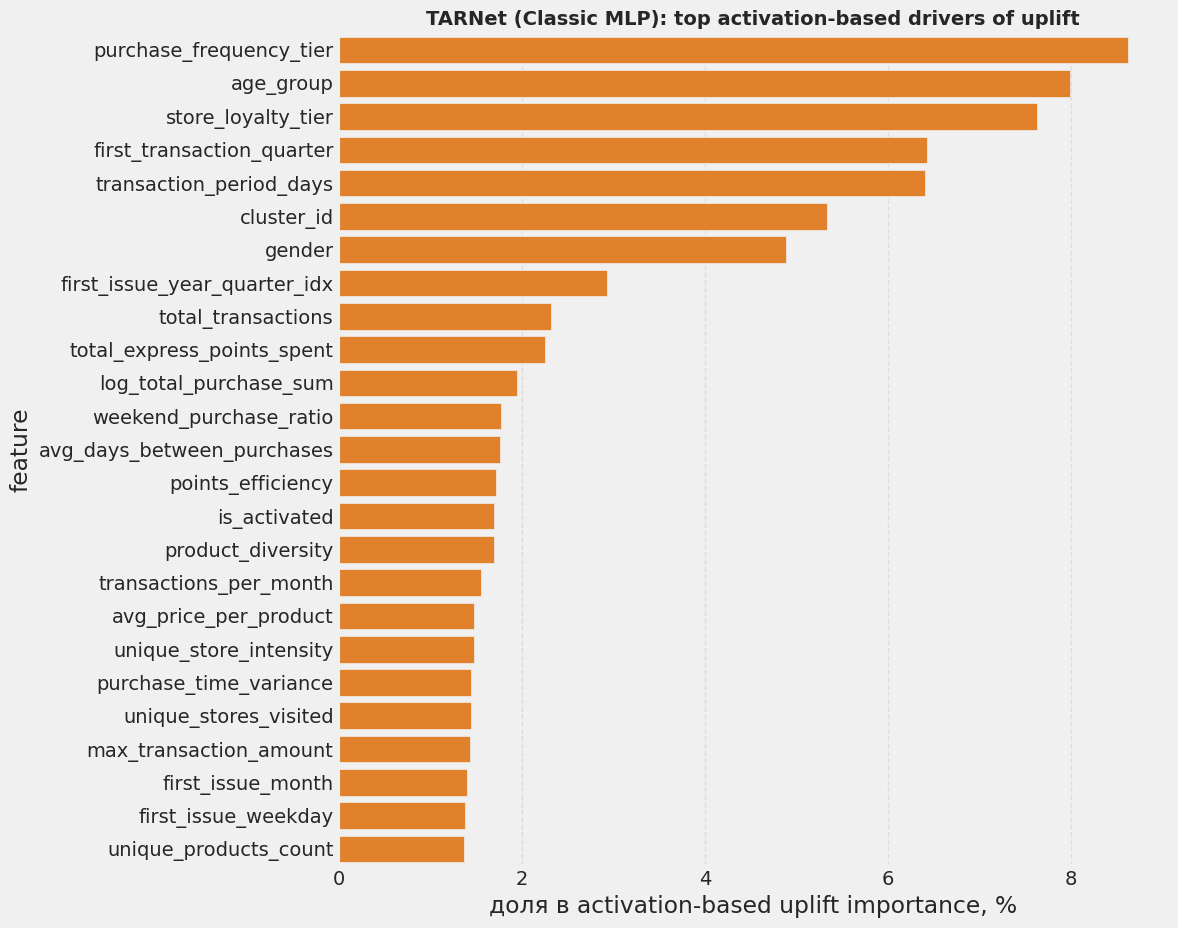

,feature,activation_importance,activation_importance_pct
0,purchase_frequency_tier,0.030178,8.625523
1,age_group,0.027944,7.986960
2,store_loyalty_tier,0.026687,7.627875
3,first_transaction_quarter,0.022493,6.429176
4,transaction_period_days,0.022415,6.406720
5,cluster_id,0.018673,5.337057
6,gender,0.017102,4.888289
7,first_issue_year_quarter_idx,0.010265,2.933878
8,total_transactions,0.008111,2.318238
9,total_express_points_spent,0.007902,2.258443


In [ ]:
DL_MODEL_NAMES = [
    name for name in MODEL_ORDER
    if holdout_specs[name]['is_dl']
]

BEST_DL_SOURCE = 'cv'
BEST_DL_SCORE = 'AUUC'

best_dl_model_name = choose_best_dl_model_name(
    cv_results_df=cv_results_df,
    test_results_df=test_results_df,
    dl_model_names=DL_MODEL_NAMES,
    score_col=BEST_DL_SCORE,
    source=BEST_DL_SOURCE
)

print('Best DL model =', best_dl_model_name)

best_dl_model, best_dl_spec = fit_or_load_best_dl_model_for_interpretation(
    model_name=best_dl_model_name,
    holdout_specs=holdout_specs,
    x_train_full=x_train_full_raw,
    y_train_full=y_train_full,
    t_train_full=t_train_full,
    dl_model_repo=DL_MODEL_REPO,
    use_saved_dl_models=USE_SAVED_DL_MODELS,
    save_fitted_dl_models=SAVE_FITTED_DL_MODELS,
    device=DEVICE
)

X_for_importance = best_dl_spec['x_test']

importance_df_raw, importance_df_extra = compute_best_dl_activation_importance(
    model=best_dl_model,
    X=X_for_importance,
    batch_size=512,
    max_rows=4096,
    random_state=SEED
)

top_importance_df = plot_activation_importance(
    importance_df_raw,
    title=f'{best_dl_model_name}: top activation-based drivers of uplift',
    top_n=25,
    color='#ff7f0e'
)

display(top_importance_df)

**Интерпретация activation-based importance**

Анализ activation-based importance для **`TARNet (Classic MLP)`** показывает, что нейросеть в первую очередь опирается не столько на отдельные сырые денежные величины, сколько на **структурные характеристики покупательского поведения клиента**: в топ выходят `purchase_frequency_tier`, `age_group`, `store_loyalty_tier`, `first_transaction_quarter`, `transaction_period_days` и `cluster_id`. Это согласуется с логикой архитектуры TARNet: модель строит общее латентное представление клиента и затем оценивает два потенциальных исхода, поэтому для неё особенно важны признаки, которые задают **тип клиента**, его стадию жизненного цикла и общий стиль взаимодействия с ритейлом. Далее в списке остаются признаки интенсивности и ценности поведения - `total_transactions`, `total_express_points_spent`, `log_total_purchase_sum`, `avg_days_between_purchases`, `transactions_per_month`, `avg_price_per_product`, `unique_stores_visited`, `unique_products_count`, что подтверждает: uplift и для DL-модели определяется сочетанием **лояльности, частоты, денежного объёма и поведенческого разнообразия**. Важно, что `cluster_id` вошёл в топ-6: это подтверждает вывод из анализа `X-Learner` в прошлом ноутбуке, где существенную роль играли кластерные/геометрические признаки (`dist_to_centroid_*`, хотя ранее прямая принадлежность к кластеру становилась менее значимой) и признаки клиентской давности (`first_issue_year_quarter_idx`), а также `total_express_points_spent`, `log_total_purchase_sum`, `transaction_period_days`, `total_transactions`, `is_activated`, `purchase_time_variance`, `avg_days_between_purchases`. То есть и ML, и DL-подход сходятся в одном и том же выводе: uplift сильнее всего связан не с одной отдельной покупкой, а с **портретом клиента как поведенческого сегмента** - его давностью в программе, частотой покупок, паттерном трат/баллов, общей интенсивностью и принадлежностью к определённому кластеру. Разница в том, что `X-Learner` сильнее выделял непрерывные monetary/points-признаки и расстояния до центроидов, тогда как `TARNet` сильнее опирается на более крупные категориальные и сегментные признаки (`*_tier`, `age_group`, `cluster_id`), что актуально для нейросети с embeddings и общей скрытой репрезентацией.
